# Analysis of InfoGap's annotations of WikiMT data

## Compute Symmetric Reference Divergence

For each article pair, we compute a **symmetric reference divergence** metric based on the yes/no intersection labels from the InfoGap pipeline:

$$D_{\text{yes/no}} = 1 - \frac{Y_S + Y_T}{F_S + F_T}$$

Where:
- $F_S$ = number of facts in source article
- $F_T$ = number of facts in target article  
- $Y_S$ = number of source facts present in target (sum of yes labels)
- $Y_T$ = number of target facts present in source (sum of yes labels)

**Interpretation**: This measures the fraction of facts that are *unmatched* across both sides. A value of 0 means perfect overlap; 1 means no overlap.

In [1]:
ANNOTATIONS_DIR = "/Users/llupo/dev/infogap/scratch/annotation_save/wikigap_data"

WIKIMT_DIV_DIR = "/Users/llupo/dev/wiki_mt/data/outputs/divergence_analysis"
WIKIMT_DIV_TREAT = "/Users/llupo/dev/wiki_mt/data/outputs/divergence_analysis/article_divergence_fr_treatment.parquet"
WIKIMT_DIV_CONTROL = "/Users/llupo/dev/wiki_mt/data/outputs/divergence_analysis/article_divergence_fr_control.parquet"

WIKIMT_TREAT_GROUP = "/Users/llupo/dev/wiki_mt/data/parallel_corpora_enriched_split/en/fr/treatment_group_rebalanced_after_sent_div_06B_d30.csv"
WIKIMT_CONTROL_GROUP = "/Users/llupo/dev/wiki_mt/data/parallel_corpora_enriched_split/en/fr/control_group_rebalanced_after_sent_div_06B_d30.csv"

In [2]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ==============================================================================
# STEP 1: Load annotation files and detect duplicates
# ==============================================================================

annotation_dir = ANNOTATIONS_DIR
annotation_files = list(Path(annotation_dir).glob("annotation_*.json"))

print(f"Found {len(annotation_files)} total annotation files\n")

# Group files by article name (extract from filename)
# Filename format: annotation_YYYY-MM-DD_ArticleName_lang.json
article_files = defaultdict(list)

for f in annotation_files:
    # Parse filename: annotation_2025-10-27_Article Name_fr.json
    # Strategy: split by '_', extract date (position 1), and reconstruct article name
    parts = f.stem.split('_')
    
    if len(parts) >= 3:
        date = parts[1]  # '2025-10-27'
        lang = parts[-1]  # 'fr' or 'en'
        
        # Article name is everything between date and language
        article_name_parts = parts[2:-1]
        article_name = '_'.join(article_name_parts)
        
        # Use article name + language as unique key
        unique_key = f"{article_name}_{lang}"
        
        article_files[unique_key].append((date, f))

# Count unique articles (ignoring language suffix)
unique_articles = set()
for key in article_files.keys():
    article_base = '_'.join(key.split('_')[:-1]) if '_' in key else key
    unique_articles.add(article_base)

print(f"Found {len(unique_articles)} unique articles ({len(article_files)} article-language pairs)")

# ==============================================================================
# STEP 2: Remove duplicates (keep most recent)
# ==============================================================================

duplicates_found = 0
files_to_remove = []

for article_key, files in article_files.items():
    if len(files) > 1:
        duplicates_found += 1
        # Sort by date (descending) to keep the most recent
        files.sort(reverse=True)
        most_recent = files[0]
        older_files = files[1:]
        
        print(f"\n  Duplicate: {article_key}")
        print(f"    ✓ Keeping:  {most_recent[1].name} ({most_recent[0]})")
        for date, f in older_files:
            print(f"    ✗ Removing: {f.name} ({date})")
            files_to_remove.append(f)

if files_to_remove:
    print(f"\n{'='*70}")
    print(f"Found {len(files_to_remove)} duplicate files - removing them...")
    print(f"{'='*70}\n")
    
    for f in files_to_remove:
        f.unlink()
        print(f"  Deleted: {f.name}")
    
    print(f"\n✓ Cleanup complete! Removed {len(files_to_remove)} files.")
    
    # Refresh file list after deletion
    annotation_files = list(annotation_dir.glob("annotation_*.json"))
    print(f"✓ {len(annotation_files)} files remaining\n")
else:
    print("\n✓ No duplicate files found!\n")

# ==============================================================================
# STEP 3: Load annotation files into DataFrames
# ==============================================================================

print(f"{'='*70}")
print("Loading annotation files...")
print(f"{'='*70}\n")

output_dfs = []

for ann_file in annotation_files:
    try:
        with open(ann_file, 'r') as f:
            data = json.load(f)
        
        # Parse the Polars JSON structure
        columns_data = {}
        for col in data['columns']:
            col_name = col['name']
            values = col['values']
            
            # Handle nested list structures
            if col['datatype'] == {'List': 'Utf8'} or \
               col['datatype'] == {'List': {'List': 'Utf8'}} or \
               col['datatype'] == {'List': 'Float64'}:
                columns_data[col_name] = values
            else:
                columns_data[col_name] = values
        
        # Create DataFrame with key columns
        df = pd.DataFrame({
            'fact': columns_data['fact'],
            'person_name': columns_data['person_name'],
            'language': columns_data['language'],
            'intersection_label': columns_data['intersection_label']
        })
        
        # Store filename for reference
        df.attrs['filename'] = ann_file.name
        
        output_dfs.append(df)
        
    except Exception as e:
        print(f"  ✗ Error loading {ann_file.name}: {e}")
        continue

print(f"✓ Successfully loaded {len(output_dfs)} annotation files\n")

# ==============================================================================
# STEP 4: Compute divergence for each article pair
# ==============================================================================

print(f"{'='*70}")
print("Computing reference divergence...")
print(f"{'='*70}\n")

def compute_reference_divergence(df, min_facts=6):
    """
    Compute symmetric reference divergence for an article pair.
    
    Returns dict with divergence metrics.
    """
    # Identify source and target languages
    languages = df['language'].unique()
    if len(languages) != 2:
        return {
            'divergence': None,
            'F_S': 0, 'F_T': 0, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Expected 2 languages, found {len(languages)}'
        }
    
    src_lang, tgt_lang = languages[0], languages[1]
    
    # Get source and target subsets
    df_src = df[df['language'] == src_lang]
    df_tgt = df[df['language'] == tgt_lang]
    
    # Count facts
    F_S = len(df_src)
    F_T = len(df_tgt)
    
    # Check minimum threshold
    if F_S + F_T < min_facts:
        return {
            'divergence': None,
            'F_S': F_S, 'F_T': F_T, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Too few facts: F_S + F_T = {F_S + F_T} < {min_facts}'
        }
    
    # Count matches (yes labels)
    def count_yes(labels_series):
        count = 0
        for label in labels_series:
            if isinstance(label, str):
                label_lower = label.lower().strip()
                if label_lower == 'yes' or label_lower == 'y':
                    count += 1
        return count
    
    Y_S = count_yes(df_src['intersection_label'])
    Y_T = count_yes(df_tgt['intersection_label'])
    
    # Compute divergence
    divergence = 1 - (Y_S + Y_T) / (F_S + F_T)
    
    return {
        'divergence': divergence,
        'F_S': F_S,
        'F_T': F_T,
        'Y_S': Y_S,
        'Y_T': Y_T,
        'excluded': False,
        'reason': None,
        'src_lang': src_lang,
        'tgt_lang': tgt_lang
    }

# Compute divergence for each article pair
divergence_results = []

for i, df in enumerate(output_dfs):
    result = compute_reference_divergence(df, min_facts=6)
    
    # Get article name
    if 'person_name' in df.columns:
        person_names = df['person_name'].unique()
        article_name = person_names[0] if len(person_names) > 0 else f'Article_{i}'
    else:
        article_name = f'Article_{i}'
    
    result['article'] = article_name
    result['filename'] = df.attrs.get('filename', f'unknown_{i}')
    divergence_results.append(result)
    
    # Print result
    if result['excluded']:
        print(f"⚠️  {article_name}: EXCLUDED - {result['reason']}")
    else:
        src_lang = result.get('src_lang', 'src')
        tgt_lang = result.get('tgt_lang', 'tgt')
        print(f"✓ {article_name} ({src_lang}↔{tgt_lang}):")
        print(f"  D_yes/no = {result['divergence']:.3f}")
        print(f"  Facts: F_{src_lang}={result['F_S']}, F_{tgt_lang}={result['F_T']}")
        print(f"  Matched: Y_{src_lang}={result['Y_S']}, Y_{tgt_lang}={result['Y_T']}")
        if result['F_S'] > 0 and result['F_T'] > 0:
            print(f"  Recall_{src_lang}={result['Y_S']/result['F_S']:.2%}, "
                  f"Recall_{tgt_lang}={result['Y_T']/result['F_T']:.2%}")
        print()

# ==============================================================================
# STEP 5: Create summary DataFrame
# ==============================================================================

divergence_df = pd.DataFrame(divergence_results)

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
display_cols = ['article', 'divergence', 'F_S', 'F_T', 'Y_S', 'Y_T', 'excluded']
print(divergence_df[display_cols].to_string(index=False))

non_excluded = divergence_df[~divergence_df['excluded']]
if len(non_excluded) > 0:
    print(f"\nStatistics (non-excluded articles):")
    print(f"  Count: {len(non_excluded)}")
    print(f"  Mean divergence: {non_excluded['divergence'].mean():.3f}")
    print(f"  Median divergence: {non_excluded['divergence'].median():.3f}")
    print(f"  Min divergence: {non_excluded['divergence'].min():.3f}")
    print(f"  Max divergence: {non_excluded['divergence'].max():.3f}")
    print(f"  Std divergence: {non_excluded['divergence'].std():.3f}")
else:
    print("\n⚠️  No valid article pairs to compute statistics")

# Display the DataFrame
divergence_df.head(3)


/Users/llupo/miniconda3/envs/mentalenv/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Found 217 total annotation files

Found 217 unique articles (217 article-language pairs)

✓ No duplicate files found!

Loading annotation files...

✓ Successfully loaded 217 annotation files

Computing reference divergence...

✓ Benjamin Smith (Whig politician) (en↔fr):
  D_yes/no = 0.101
  Facts: F_en=51, F_fr=38
  Matched: Y_en=47, Y_fr=33
  Recall_en=92.16%, Recall_fr=86.84%

✓ Muskrat River (Ontario) (fr↔en):
  D_yes/no = 0.222
  Facts: F_fr=9, F_en=18
  Matched: Y_fr=9, Y_en=12
  Recall_fr=100.00%, Recall_en=66.67%

⚠️  Retaliate (Misery Index album): EXCLUDED - Too few facts: F_S + F_T = 3 < 6
✓ Private town (en↔fr):
  D_yes/no = 0.235
  Facts: F_en=47, F_fr=21
  Matched: Y_en=36, Y_fr=16
  Recall_en=76.60%, Recall_fr=76.19%

✓ Charles Cust (en↔fr):
  D_yes/no = 0.184
  Facts: F_en=20, F_fr=18
  Matched: Y_en=15, Y_fr=16
  Recall_en=75.00%, Recall_fr=88.89%

✓ Mastoid cells (fr↔en):
  D_yes/no = 0.120
  Facts: F_fr=24, F_en=26
  Matched: Y_fr=22, Y_en=22
  Recall_fr=91.67%, Recal

,divergence,F_S,F_T,Y_S,Y_T,excluded,reason,src_lang,tgt_lang,article,filename
0,0.101124,51,38,47,33,False,None,en,fr,Benjamin Smith (Whig politician),annotation_2025-10-27_Benjamin Smith (Whig pol...
1,0.222222,9,18,9,12,False,None,fr,en,Muskrat River (Ontario),annotation_2025-10-31_Muskrat River (Ontario)_...
2,NaN,1,2,0,0,True,Too few facts: F_S + F_T = 3 < 6,NaN,NaN,Retaliate (Misery Index album),annotation_2025-10-28_Retaliate (Misery Index ...


## Compare Our Method's Divergence Score and Reference Divergence

## Match InfoGap Articles with Wiki_MT Groups

This section:
1. Loads Wiki_MT treatment and control divergence parquet files
2. Maps QIDs to article titles for control group (using JSON file)
3. Creates article-to-group mapping
4. Assigns each InfoGap article to treatment/control group

**Note**: Control group parquet only has QIDs, not article titles, so we need to map them from the JSON source.

In [3]:
# Load Wiki_MT treatment and control divergence data
wikimt_div_dir = Path(WIKIMT_DIV_DIR)

df_fr_treatment = pd.read_parquet(wikimt_div_dir / "article_divergence_fr_treatment.parquet")
df_fr_control = pd.read_parquet(wikimt_div_dir / "article_divergence_fr_control.parquet")

print(f"Wiki_MT Treatment articles: {len(df_fr_treatment)}")
print(f"Wiki_MT Control articles: {len(df_fr_control)}")

# Create mapping of article names to groups
# Treatment parquet has sourceTitle and targetTitle columns
treatment_articles = set(df_fr_treatment['sourceTitle'].dropna()) | set(df_fr_treatment['targetTitle'].dropna())

# Control parquet only has QIDs, so we need to map them to titles using the JSON files
# Load control JSON to map QIDs to article titles
import ijson

json_dir = Path("/Users/llupo/dev/wiki_mt/data/parallel_corpora_enriched_split/en/fr/")
control_json = json_dir / "revision_history_contents_control.json"

print(f"\nBuilding QID-to-title mapping from control JSON...")
qid_to_title = {}

if control_json.exists():
    with open(control_json, 'rb') as f:
        for article in ijson.items(f, 'item'):
            qid = article.get('qid')
            source_title = article.get('sourceTitle')
            
            if qid and source_title:
                qid_to_title[qid] = source_title
    
    print(f"Mapped {len(qid_to_title)} QIDs to titles")
    
    # Map control parquet QIDs to titles
    df_fr_control['sourceTitle'] = df_fr_control['qid'].map(qid_to_title)
    control_articles = set(df_fr_control['sourceTitle'].dropna())
    print(f"Control articles with titles: {len(control_articles)}")
else:
    print(f"WARNING: Control JSON not found at {control_json}")
    control_articles = set()

# Create article-to-group mapping
article_to_group = {}
for article in treatment_articles:
    article_to_group[article] = 'treatment'
for article in control_articles:
    article_to_group[article] = 'control'

print(f"\nTotal articles mapped:")
print(f"  Treatment: {sum(1 for g in article_to_group.values() if g == 'treatment')}")
print(f"  Control: {sum(1 for g in article_to_group.values() if g == 'control')}")

# Map InfoGap articles to groups
divergence_df['wikimt_group'] = divergence_df['article'].map(article_to_group)

print(f"\n=== InfoGap Article Matching ===")
print(f"InfoGap articles analyzed: {len(divergence_df)}")
print(f"Matched to treatment: {(divergence_df['wikimt_group'] == 'treatment').sum()}")
print(f"Matched to control: {(divergence_df['wikimt_group'] == 'control').sum()}")
print(f"Unmatched: {divergence_df['wikimt_group'].isna().sum()}")

# Show unmatched articles
unmatched = divergence_df[divergence_df['wikimt_group'].isna()]['article'].tolist()
if unmatched:
    print(f"\nUnmatched articles:")
    for art in unmatched:
        print(f"  - {art}")

Wiki_MT Treatment articles: 75784
Wiki_MT Control articles: 75784

Building QID-to-title mapping from control JSON...
Mapped 82800 QIDs to titles
Control articles with titles: 34947

Total articles mapped:
  Treatment: 112041
  Control: 34947

=== InfoGap Article Matching ===
InfoGap articles analyzed: 217
Matched to treatment: 210
Matched to control: 0
Unmatched: 7

Unmatched articles:
  - Megan Ambuhl
  - John Caley
  - Anna Lisitsyna
  - French ship Diadème (1811)
  - Mikaela Loach
  - Muntzing
  - Angel Romero (guitarist)
Mapped 82800 QIDs to titles
Control articles with titles: 34947

Total articles mapped:
  Treatment: 112041
  Control: 34947

=== InfoGap Article Matching ===
InfoGap articles analyzed: 217
Matched to treatment: 210
Matched to control: 0
Unmatched: 7

Unmatched articles:
  - Megan Ambuhl
  - John Caley
  - Anna Lisitsyna
  - French ship Diadème (1811)
  - Mikaela Loach
  - Muntzing
  - Angel Romero (guitarist)


## Statistical Test: Treatment vs Control Groups

Test whether InfoGap divergence differs significantly between treatment and control groups.

In [4]:
# Filter out unmatched articles and create comparison dataframe
comparison_df = divergence_df[divergence_df['wikimt_group'].notna()].copy()

print("="*80)
print("Treatment vs Control Comparison")
print("="*80)

# Check if we have both groups
n_treatment = (comparison_df['wikimt_group'] == 'treatment').sum()
n_control = (comparison_df['wikimt_group'] == 'control').sum()

print(f"\nSample sizes:")
print(f"  Treatment: {n_treatment}")
print(f"  Control: {n_control}")

if n_treatment > 0 and n_control > 0:
    print(f"\n✅ Both groups available - proceeding with analysis")
    
    # Summary statistics by group
    print(f"\n{'='*80}")
    print("Summary Statistics by Group")
    print(f"{'='*80}\n")
    
    for group in ['treatment', 'control']:
        group_data = comparison_df[comparison_df['wikimt_group'] == group]['divergence']
        print(f"{group.upper()} Group (n={len(group_data)}):")
        print(f"  Mean: {group_data.mean():.4f}")
        print(f"  Median: {group_data.median():.4f}")
        print(f"  Std: {group_data.std():.4f}")
        print(f"  Min: {group_data.min():.4f}")
        print(f"  Max: {group_data.max():.4f}")
        print()
    
    # Perform statistical test
    from scipy import stats
    
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    control_div = comparison_df[comparison_df['wikimt_group'] == 'control']['divergence']
    
    # Two-sample t-test
    t_stat, p_value = stats.ttest_ind(treatment_div, control_div)
    
    print(f"{'='*80}")
    print("Two-Sample t-test")
    print(f"{'='*80}")
    print(f"H0: Mean divergence is equal between treatment and control")
    print(f"H1: Mean divergence differs between treatment and control")
    print(f"\nTest statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"✅ Result: SIGNIFICANT (p < 0.05)")
        print(f"   Reject null hypothesis - groups differ significantly")
    else:
        print(f"⚠️  Result: NOT SIGNIFICANT (p >= 0.05)")
        print(f"   Fail to reject null hypothesis - no significant difference")
    
    # Effect size (Cohen's d)
    pooled_std = ((treatment_div.std()**2 + control_div.std()**2) / 2)**0.5
    cohens_d = (treatment_div.mean() - control_div.mean()) / pooled_std
    print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
    
elif n_treatment > 0:
    print(f"\n⚠️  WARNING: Only treatment group available")
    print(f"   InfoGap pipeline needs to be run on control articles")
    print(f"   Statistical comparison cannot be performed yet")
    
elif n_control > 0:
    print(f"\n⚠️  WARNING: Only control group available")
    print(f"   Statistical comparison cannot be performed yet")
    
else:
    print(f"\n❌ ERROR: No matched articles found")
    print(f"   Check that article names match between InfoGap and Wiki_MT datasets")

Treatment vs Control Comparison

Sample sizes:
  Treatment: 210
  Control: 0

⚠️  WARNING: Only treatment group available
   InfoGap pipeline needs to be run on control articles
   Statistical comparison cannot be performed yet



⚠️  Only treatment group available - showing treatment distribution only


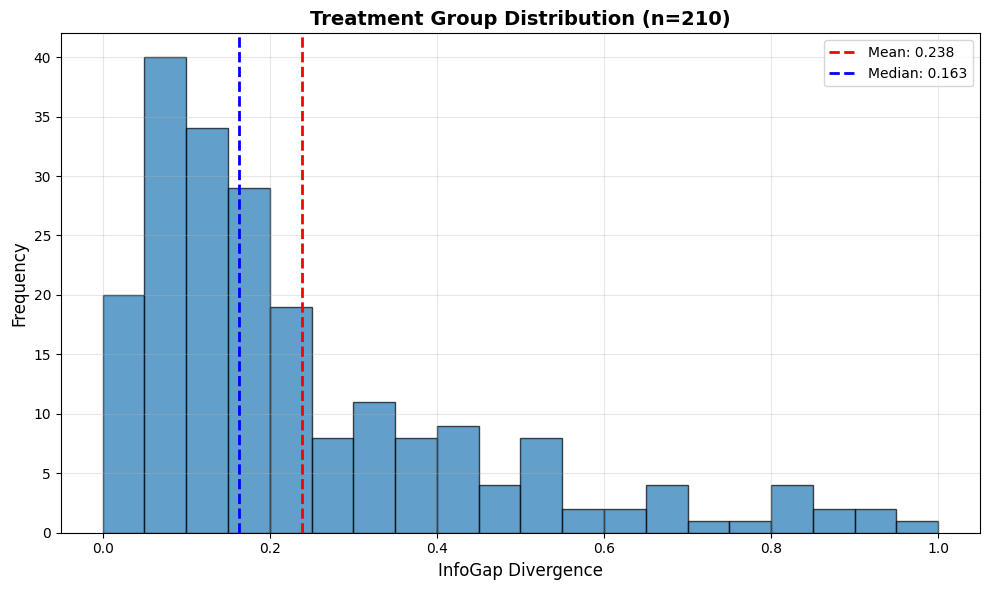

In [5]:
# ==============================================================================
# Visualize Treatment vs Control Divergence
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Check if we have both groups
n_treatment = (comparison_df['wikimt_group'] == 'treatment').sum()
n_control = (comparison_df['wikimt_group'] == 'control').sum()

if n_treatment > 0 and n_control > 0:
    print(f"\n{'='*80}")
    print("Visualizing Treatment vs Control")
    print(f"{'='*80}\n")
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('InfoGap Divergence: Treatment vs Control', fontsize=16, fontweight='bold')
    
    # 1. Box plot
    ax = axes[0, 0]
    sns.boxplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Distribution by Group', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Violin plot
    ax = axes[0, 1]
    sns.violinplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Density Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Histogram
    ax = axes[1, 0]
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    control_div = comparison_df[comparison_df['wikimt_group'] == 'control']['divergence']
    
    ax.hist([treatment_div, control_div], bins=20, alpha=0.6, label=['Treatment', 'Control'])
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Strip plot with means
    ax = axes[1, 1]
    sns.stripplot(data=comparison_df, x='wikimt_group', y='divergence', alpha=0.4, ax=ax)
    
    # Add mean lines
    for group in ['treatment', 'control']:
        group_mean = comparison_df[comparison_df['wikimt_group'] == group]['divergence'].mean()
        x_pos = 0 if group == 'treatment' else 1
        ax.plot([x_pos - 0.3, x_pos + 0.3], [group_mean, group_mean], 
                color='red', linewidth=2, label=f'{group.capitalize()} mean' if group == 'treatment' else None)
    
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Individual Points with Means', fontsize=12, fontweight='bold')
    ax.legend(['Mean'], loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional: QQ-plot to check normality
    from scipy import stats
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Normality Check: QQ-Plots', fontsize=14, fontweight='bold')
    
    for i, group in enumerate(['treatment', 'control']):
        group_data = comparison_df[comparison_df['wikimt_group'] == group]['divergence']
        stats.probplot(group_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'{group.capitalize()} Group (n={len(group_data)})', fontsize=12)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

elif n_treatment > 0:
    print(f"\n⚠️  Only treatment group available - showing treatment distribution only")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    
    ax.hist(treatment_div, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(treatment_div.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {treatment_div.mean():.3f}')
    ax.axvline(treatment_div.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {treatment_div.median():.3f}')
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Treatment Group Distribution (n={len(treatment_div)})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n❌ No data available for visualization")

In [6]:
# ==============================================================================
# Treatment Effect Estimation: InfoGap Divergence (OLS Regression Framework)
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

ALPHA = 0.05
MIN_PER_ARM = 3  # Minimum observations per arm for estimation

print("="*80)
print("TREATMENT EFFECT ESTIMATION: INFOGAP DIVERGENCE")
print("="*80)

# -----------------------------------------------------------------------------
# 1. Check data availability
# -----------------------------------------------------------------------------
if 'wikimt_group' not in comparison_df.columns:
    print("\n⚠️  ERROR: No group information available")
    print("Available columns:", comparison_df.columns.tolist())
    print("\nTo perform treatment effect estimation, you need:")
    print("  1. A 'wikimt_group' column with 'treatment' and 'control' labels")
    print("  2. Both treatment and control articles in your comparison_df")
    print("\nCurrent situation: comparison_df only contains articles from one source.")
    print("You need to run the InfoGap pipeline on BOTH treatment and control articles.")
    
else:
    # Prepare data
    df_model = comparison_df.dropna(subset=['divergence']).copy()
    df_model['group'] = df_model['wikimt_group'].astype('category')
    
    n_treat = (df_model['group'] == 'treatment').sum()
    n_control = (df_model['group'] == 'control').sum()
    
    print(f"\nSample sizes:")
    print(f"  Treatment: n = {n_treat}")
    print(f"  Control:   n = {n_control}")
    
    if n_control == 0:
        print(f"\n{'='*80}")
        print("⚠️  INSUFFICIENT DATA FOR TREATMENT EFFECT ESTIMATION")
        print(f"{'='*80}")
        print("\nYou have ZERO control group articles!")
        print("\nTo estimate treatment effects, you need:")
        print("  - At least 3 treatment articles (you have: {})".format(n_treat))
        print("  - At least 3 control articles (you have: 0)")
        print("\nNext steps:")
        print("  1. Sample control group articles from your wiki_mt data")
        print("  2. Run the InfoGap pipeline on those articles")
        print("  3. Merge the results into comparison_df with group='control'")
        print("  4. Re-run this cell")
        
        print(f"\n{'='*80}")
        print("DESCRIPTIVE STATISTICS (Treatment only)")
        print(f"{'='*80}")
        treat_div = df_model[df_model['group']=='treatment']['divergence']
        print(f"\nTreatment Group:")
        print(f"  Mean:   {treat_div.mean():.4f}")
        print(f"  Median: {treat_div.median():.4f}")
        print(f"  Std:    {treat_div.std():.4f}")
        print(f"  Min:    {treat_div.min():.4f}")
        print(f"  Max:    {treat_div.max():.4f}")
        
    elif min(n_treat, n_control) < MIN_PER_ARM:
        print(f"\n⚠️  WARNING: Sample size too small for reliable estimation")
        print(f"   Minimum required per arm: {MIN_PER_ARM}")
        print(f"   Proceeding with caution...")
        
        # Simple comparison (no covariates)
        print(f"\n{'='*80}")
        print("SIMPLE COMPARISON (No Covariates)")
        print(f"{'='*80}")
        
        treat_div = df_model[df_model['group']=='treatment']['divergence']
        control_div = df_model[df_model['group']=='control']['divergence']
        
        print(f"\nTreatment: Mean = {treat_div.mean():.4f}, SD = {treat_div.std():.4f}")
        print(f"Control:   Mean = {control_div.mean():.4f}, SD = {control_div.std():.4f}")
        print(f"\nNaive difference: {treat_div.mean() - control_div.mean():.4f}")
        
        # T-test
        t_stat, p_val = stats.ttest_ind(treat_div, control_div)
        print(f"\nT-test: t = {t_stat:.3f}, p = {p_val:.4f}")
        
        if p_val < ALPHA:
            print(f"  Result: * SIGNIFICANT at α={ALPHA}")
        else:
            print(f"  Result: NOT SIGNIFICANT at α={ALPHA}")
    
    else:
        # ---------------------------------------------------------------------
        # 2. Sufficient data: run OLS regression
        # ---------------------------------------------------------------------
        print(f"\n{'='*80}")
        print("OLS REGRESSION ESTIMATION")
        print(f"{'='*80}")
        
        # Check available covariates
        covariates = []
        if 'F_S' in df_model.columns and 'F_T' in df_model.columns:
            df_model['total_facts'] = df_model['F_S'] + df_model['F_T']
            df_model['log_facts'] = np.log1p(df_model['total_facts'])
            df_model['log_facts_c'] = df_model['log_facts'] - df_model['log_facts'].mean()
            covariates.append('log_facts_c')
        
        # Build formula
        if covariates:
            formula = f"divergence ~ group + {' + '.join(covariates)}"
        else:
            formula = "divergence ~ group"
        
        print(f"\nFormula: {formula}")
        
        # Fit model
        try:
            ols_model = smf.ols(formula, data=df_model).fit(cov_type='HC3')
            
            print(f"\n{ols_model.summary()}")
            
            # ---------------------------------------------------------------------
            # 3. Compute average treatment effect (ATE)
            # ---------------------------------------------------------------------
            print(f"\n{'='*80}")
            print("AVERAGE TREATMENT EFFECT (ATE)")
            print(f"{'='*80}")
            
            # Counterfactual predictions
            t_df = df_model.copy()
            t_df['group'] = 'treatment'
            c_df = df_model.copy()
            c_df['group'] = 'control'
            
            pred_t = ols_model.get_prediction(t_df)
            pred_c = ols_model.get_prediction(c_df)
            
            ate = pred_t.predicted_mean.mean() - pred_c.predicted_mean.mean()
            se_t = pred_t.se_mean.mean()
            se_c = pred_c.se_mean.mean()
            se_ate = np.sqrt(se_t**2 + se_c**2)
            
            t_crit = stats.t.ppf(1 - ALPHA/2, ols_model.df_resid)
            ci_lower = ate - t_crit * se_ate
            ci_upper = ate + t_crit * se_ate
            p_value = 2 * (1 - stats.t.cdf(abs(ate / se_ate) if se_ate > 0 else np.inf, 
                                           ols_model.df_resid))
            
            print(f"\nEstimated ATE: {ate:.4f}")
            print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
            print(f"p-value: {p_value:.4f}")
            
            if p_value < 0.001:
                sig_label = "*** (p < 0.001)"
            elif p_value < 0.01:
                sig_label = "** (p < 0.01)"
            elif p_value < ALPHA:
                sig_label = f"* (p < {ALPHA})"
            else:
                sig_label = "not significant"
            
            print(f"Significance: {sig_label}")
            
            # ---------------------------------------------------------------------
            # 4. Visualization
            # ---------------------------------------------------------------------
            print(f"\n{'='*80}")
            print("VISUALIZATION")
            print(f"{'='*80}\n")
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Forest plot
            ax1 = axes[0]
            ax1.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            ax1.plot([ci_lower, ci_upper], [0, 0], 'b-', linewidth=3)
            ax1.scatter(ate, 0, color='darkblue', s=150, zorder=3, edgecolor='black', linewidth=2)
            
            if p_value < ALPHA:
                ax1.text(ate, 0.08, '＊', ha='center', va='bottom', fontsize=16, 
                        fontweight='bold', color='darkblue')
            
            ax1.set_yticks([])
            ax1.set_xlabel('Treatment Effect (ATE)', fontsize=12)
            ax1.set_title('Average Treatment Effect\n(Treatment - Control)', 
                         fontsize=13, fontweight='bold')
            ax1.grid(axis='x', linestyle=':', alpha=0.4)
            ax1.text(0.02, 0.98, f'ATE = {ate:.4f}\np = {p_value:.4f}',
                    transform=ax1.transAxes, fontsize=11,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Box plot comparison
            ax2 = axes[1]
            treat_vals = df_model[df_model['group']=='treatment']['infogap_divergence']
            control_vals = df_model[df_model['group']=='control']['infogap_divergence']
            
            bp = ax2.boxplot([treat_vals, control_vals], 
                            labels=['Treatment', 'Control'],
                            patch_artist=True, widths=0.5)
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightblue')
            
            ax2.set_ylabel('InfoGap Divergence', fontsize=12)
            ax2.set_title('Distribution by Group', fontsize=13, fontweight='bold')
            ax2.grid(axis='y', alpha=0.3)
            
            # Add sample sizes
            ax2.text(1, ax2.get_ylim()[0], f'n={len(treat_vals)}', 
                    ha='center', va='top', fontsize=9)
            ax2.text(2, ax2.get_ylim()[0], f'n={len(control_vals)}', 
                    ha='center', va='top', fontsize=9)
            
            plt.tight_layout()
            plt.show()
            
            # ---------------------------------------------------------------------
            # 5. Summary
            # ---------------------------------------------------------------------
            print(f"\n{'='*80}")
            print("SUMMARY & INTERPRETATION")
            print(f"{'='*80}")
            
            print(f"\nH₀: Treatment has no effect on InfoGap divergence (ATE = 0)")
            print(f"H₁: Treatment affects InfoGap divergence (ATE ≠ 0)")
            
            if p_value < ALPHA:
                direction = "INCREASES" if ate > 0 else "DECREASES"
                print(f"\n✓ REJECT H₀ (p = {p_value:.4f} < {ALPHA})")
                print(f"\nConclusion:")
                print(f"  Machine translation {direction} information divergence")
                print(f"  by {abs(ate):.4f} units on average (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
                print(f"\n  Interpretation:")
                if ate > 0:
                    print(f"    Treatment articles show MORE divergence than control articles.")
                    print(f"    This suggests MT-created articles have greater information gaps.")
                else:
                    print(f"    Treatment articles show LESS divergence than control articles.")
                    print(f"    This suggests MT-created articles have smaller information gaps.")
            else:
                print(f"\n✗ FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ {ALPHA})")
                print(f"\nConclusion:")
                print(f"  No significant effect detected.")
                print(f"  Point estimate: {ate:.4f}, but not statistically distinguishable from zero.")
                print(f"\n  Possible reasons:")
                print(f"    - True effect is small or non-existent")
                print(f"    - Sample size too small (consider collecting more data)")
                print(f"    - High variability in the outcome")
            
        except Exception as e:
            print(f"\n⚠️  ERROR: OLS estimation failed")
            print(f"   {str(e)}")
            print(f"\n   Falling back to simple comparison...")

print(f"\n{'='*80}")
print("DATA SUMMARY")
print(f"{'='*80}\n")
display_cols = ['article', 'infogap_divergence', 'wikimt_group', 'infogap_F_S', 'infogap_F_T']
avail_cols = [c for c in display_cols if c in comparison_df.columns]
print(comparison_df[avail_cols].sort_values('wikimt_group' if 'wikimt_group' in avail_cols else avail_cols[0]).to_string(index=False))

TREATMENT EFFECT ESTIMATION: INFOGAP DIVERGENCE

Sample sizes:
  Treatment: n = 209
  Control:   n = 0

⚠️  INSUFFICIENT DATA FOR TREATMENT EFFECT ESTIMATION

You have ZERO control group articles!

To estimate treatment effects, you need:
  - At least 3 treatment articles (you have: 209)
  - At least 3 control articles (you have: 0)

Next steps:
  1. Sample control group articles from your wiki_mt data
  2. Run the InfoGap pipeline on those articles
  3. Merge the results into comparison_df with group='control'
  4. Re-run this cell

DESCRIPTIVE STATISTICS (Treatment only)

Treatment Group:
  Mean:   0.2380
  Median: 0.1628
  Std:    0.2125
  Min:    0.0000
  Max:    1.0000

DATA SUMMARY

                                                                article wikimt_group
                                       Benjamin Smith (Whig politician)    treatment
                                        Paramount Theatre (Los Angeles)    treatment
                                               

## Compare InfoGap vs Wiki_MT Divergence Scores

Compare our InfoGap divergence metric with Wiki_MT's existing divergence scores (prop_above_threshold) for the same articles.

In [7]:
# ==============================================================================
# Match InfoGap articles with Wiki_MT divergence scores
# ==============================================================================

print("="*80)
print("Comparing InfoGap Divergence with Wiki_MT Divergence Scores")
print("="*80)

# Create a combined Wiki_MT dataframe with treatment and control
df_fr_wikimt = pd.concat([
    df_fr_treatment.assign(wikimt_group='treatment'),
    df_fr_control.assign(wikimt_group='control')
], ignore_index=True)

print(f"\nWiki_MT dataset:")
print(f"  Total articles: {len(df_fr_wikimt)}")
print(f"  Treatment: {(df_fr_wikimt['wikimt_group'] == 'treatment').sum()}")
print(f"  Control: {(df_fr_wikimt['wikimt_group'] == 'control').sum()}")

# Check available columns in Wiki_MT
avail_cols = df_fr_wikimt.columns.tolist()
print(f"\nAvailable Wiki_MT columns: {avail_cols}")

# Match articles by sourceTitle or targetTitle
matched_comparisons = []

for idx, infogap_row in divergence_df.iterrows():
    article_name = infogap_row['article']
    
    # Try matching with sourceTitle
    wikimt_match = None
    if 'sourceTitle' in df_fr_wikimt.columns:
        wikimt_match = df_fr_wikimt[df_fr_wikimt['sourceTitle'] == article_name]
    
    # If no match, try targetTitle
    if (wikimt_match is None or wikimt_match.empty) and 'targetTitle' in df_fr_wikimt.columns:
        wikimt_match = df_fr_wikimt[df_fr_wikimt['targetTitle'] == article_name]
    
    # If we found a match, record the comparison
    if wikimt_match is not None and not wikimt_match.empty:
        wikimt_row = wikimt_match.iloc[0]
        
        matched_comparisons.append({
            'article': article_name,
            'infogap_divergence': infogap_row['divergence'],
            'infogap_F_S': infogap_row['F_S'],
            'infogap_F_T': infogap_row['F_T'],
            'infogap_Y_S': infogap_row['Y_S'],
            'infogap_Y_T': infogap_row['Y_T'],
            'wikimt_median_divergence': wikimt_row.get('median_divergence', None),
            'wikimt_prop_above_threshold': wikimt_row.get('prop_above_threshold', None),
            'wikimt_upper_percentile': wikimt_row.get('upper_percentile_score', None),
            'wikimt_group': wikimt_row.get('wikimt_group', None)
        })

# Create comparison dataframe
method_comparison_df = pd.DataFrame(matched_comparisons)

print(f"\n{'='*80}")
print("Matching Results")
print(f"{'='*80}")
print(f"InfoGap articles: {len(divergence_df)}")
print(f"Matched with Wiki_MT: {len(method_comparison_df)}")
print(f"Unmatched: {len(divergence_df) - len(method_comparison_df)}")

if len(method_comparison_df) > 0:
    print(f"\n{'='*80}")
    print("Sample Matched Articles")
    print(f"{'='*80}")
    print(method_comparison_df[['article', 'infogap_divergence', 'wikimt_prop_above_threshold', 'wikimt_group']].head(10))

Comparing InfoGap Divergence with Wiki_MT Divergence Scores

Wiki_MT dataset:
  Total articles: 151568
  Treatment: 75784
  Control: 75784

Available Wiki_MT columns: ['article_pair_id', 'sentence_count', 'median_divergence', 'prop_above_threshold', 'upper_percentile_score', 'translationId', 'sourceTitle', 'targetTitle', 'sourceLanguage', 'sourceRevisionId', 'targetRevisionId', 'targetLanguage', 'sourceURL', 'targetURL', 'publishedDate', 'stats', 'qid', 'country_prediction', 'main_topic', 'main_topic_level1', 'year', 'main_topic_cleaned', 'wikimt_group', 'sourcePageId', 'targetPageId']

Matching Results
InfoGap articles: 217
Matched with Wiki_MT: 210
Unmatched: 7

Sample Matched Articles
                            article  infogap_divergence  \
0  Benjamin Smith (Whig politician)            0.101124   
1           Muskrat River (Ontario)            0.222222   
2    Retaliate (Misery Index album)                 NaN   
3                      Private town            0.235294   
4       

In [8]:
# ==============================================================================
# Correlation Analysis: InfoGap vs Wiki_MT Divergence
# ==============================================================================

if len(method_comparison_df) > 0 and 'wikimt_prop_above_threshold' in method_comparison_df.columns:
    print(f"\n{'='*80}")
    print("Correlation Analysis")
    print(f"{'='*80}")
    
    # Clean data (remove NaN values)
    clean_df = method_comparison_df.dropna(subset=['infogap_divergence', 'wikimt_prop_above_threshold'])
    
    if len(clean_df) >= 3:
        from scipy import stats
        
        infogap_scores = clean_df['infogap_divergence']
        wikimt_scores = clean_df['wikimt_prop_above_threshold']
        
        # Pearson correlation
        pearson_r, pearson_p = stats.pearsonr(infogap_scores, wikimt_scores)
        print(f"\nPearson correlation:")
        print(f"  r = {pearson_r:.4f}")
        print(f"  p-value = {pearson_p:.4f}")
        
        if pearson_p < 0.05:
            print(f"  ✅ Significant correlation (p < 0.05)")
        else:
            print(f"  ⚠️  Not significant (p >= 0.05)")
        
        # Spearman correlation (rank-based, more robust)
        spearman_r, spearman_p = stats.spearmanr(infogap_scores, wikimt_scores)
        print(f"\nSpearman correlation (rank-based):")
        print(f"  ρ = {spearman_r:.4f}")
        print(f"  p-value = {spearman_p:.4f}")
        
        if spearman_p < 0.05:
            print(f"  ✅ Significant correlation (p < 0.05)")
        else:
            print(f"  ⚠️  Not significant (p >= 0.05)")
        
        # Summary statistics
        print(f"\n{'='*80}")
        print("Summary Statistics")
        print(f"{'='*80}")
        print(f"\nInfoGap Divergence:")
        print(f"  Mean: {infogap_scores.mean():.4f}")
        print(f"  Std: {infogap_scores.std():.4f}")
        print(f"  Range: [{infogap_scores.min():.4f}, {infogap_scores.max():.4f}]")
        
        print(f"\nWiki_MT Divergence (prop_above_threshold):")
        print(f"  Mean: {wikimt_scores.mean():.4f}")
        print(f"  Std: {wikimt_scores.std():.4f}")
        print(f"  Range: [{wikimt_scores.min():.4f}, {wikimt_scores.max():.4f}]")
    else:
        print(f"\n⚠️  Insufficient data for correlation analysis (n={len(clean_df)})")
else:
    print(f"\n⚠️  No Wiki_MT divergence scores available for comparison")


Correlation Analysis

Pearson correlation:
  r = 0.7474
  p-value = 0.0000
  ✅ Significant correlation (p < 0.05)

Spearman correlation (rank-based):
  ρ = 0.6372
  p-value = 0.0000
  ✅ Significant correlation (p < 0.05)

Summary Statistics

InfoGap Divergence:
  Mean: 0.2380
  Std: 0.2125
  Range: [0.0000, 1.0000]

Wiki_MT Divergence (prop_above_threshold):
  Mean: 0.1034
  Std: 0.1365
  Range: [0.0000, 0.6905]



Generating Visualizations



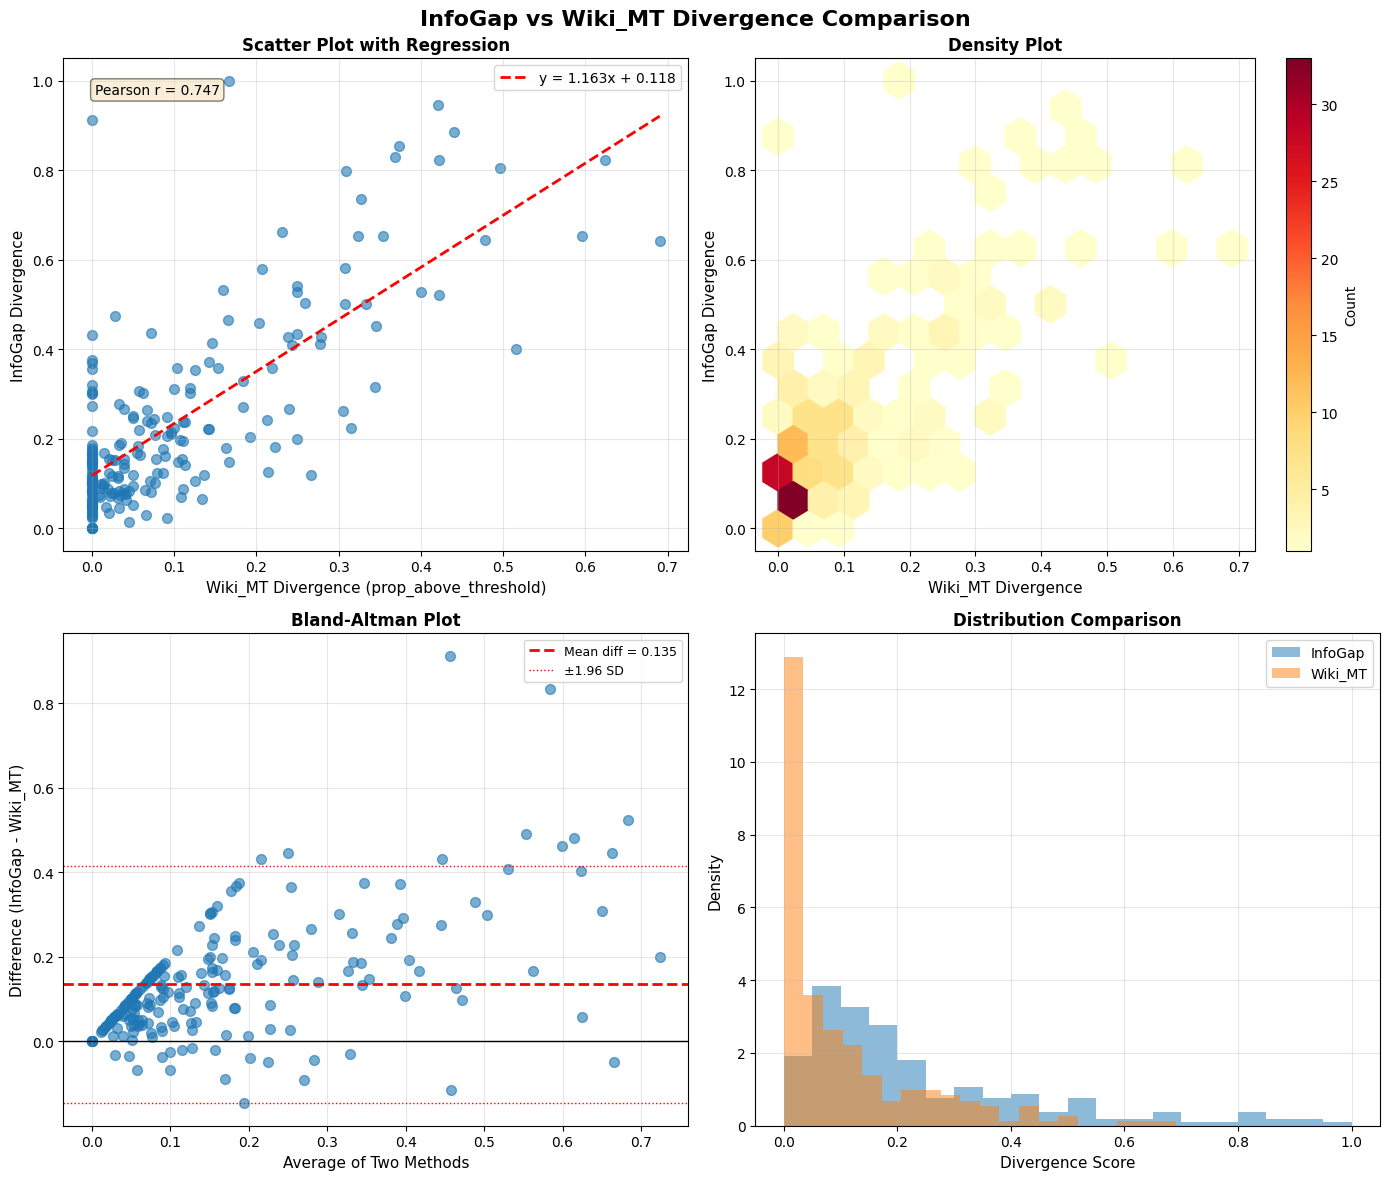

✅ Visualizations generated successfully


In [9]:
# ==============================================================================
# Visualize InfoGap vs Wiki_MT Divergence Comparison
# ==============================================================================

if len(method_comparison_df) > 0 and 'wikimt_prop_above_threshold' in method_comparison_df.columns:
    clean_df = method_comparison_df.dropna(subset=['infogap_divergence', 'wikimt_prop_above_threshold'])
    
    if len(clean_df) >= 3:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from scipy import stats
        import numpy as np
        
        print(f"\n{'='*80}")
        print("Generating Visualizations")
        print(f"{'='*80}\n")
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        fig.suptitle('InfoGap vs Wiki_MT Divergence Comparison', fontsize=16, fontweight='bold')
        
        # 1. Scatter plot with regression line
        ax = axes[0, 0]
        ax.scatter(clean_df['wikimt_prop_above_threshold'], clean_df['infogap_divergence'], 
                   alpha=0.6, s=50)
        
        # Add regression line
        x = clean_df['wikimt_prop_above_threshold']
        y = clean_df['infogap_divergence']
        
        # Check for sufficient variance before fitting
        if x.std() > 1e-10 and y.std() > 1e-10:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, p(x_line), "r--", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
            ax.legend()
        
        # Add correlation text
        pearson_r, _ = stats.pearsonr(x, y)
        ax.text(0.05, 0.95, f'Pearson r = {pearson_r:.3f}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Wiki_MT Divergence (prop_above_threshold)', fontsize=11)
        ax.set_ylabel('InfoGap Divergence', fontsize=11)
        ax.set_title('Scatter Plot with Regression', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # 2. Hexbin plot (density)
        ax = axes[0, 1]
        hexbin = ax.hexbin(clean_df['wikimt_prop_above_threshold'], clean_df['infogap_divergence'],
                           gridsize=15, cmap='YlOrRd', mincnt=1)
        plt.colorbar(hexbin, ax=ax, label='Count')
        ax.set_xlabel('Wiki_MT Divergence', fontsize=11)
        ax.set_ylabel('InfoGap Divergence', fontsize=11)
        ax.set_title('Density Plot', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # 3. Bland-Altman plot (difference vs mean)
        ax = axes[1, 0]
        mean_div = (clean_df['infogap_divergence'] + clean_df['wikimt_prop_above_threshold']) / 2
        diff_div = clean_df['infogap_divergence'] - clean_df['wikimt_prop_above_threshold']
        
        ax.scatter(mean_div, diff_div, alpha=0.6, s=50)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=diff_div.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean diff = {diff_div.mean():.3f}')
        ax.axhline(y=diff_div.mean() + 1.96*diff_div.std(), color='red', linestyle=':', linewidth=1,
                   label='±1.96 SD')
        ax.axhline(y=diff_div.mean() - 1.96*diff_div.std(), color='red', linestyle=':', linewidth=1)
        
        ax.set_xlabel('Average of Two Methods', fontsize=11)
        ax.set_ylabel('Difference (InfoGap - Wiki_MT)', fontsize=11)
        ax.set_title('Bland-Altman Plot', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # 4. Distribution comparison
        ax = axes[1, 1]
        ax.hist(clean_df['infogap_divergence'], bins=20, alpha=0.5, label='InfoGap', density=True)
        ax.hist(clean_df['wikimt_prop_above_threshold'], bins=20, alpha=0.5, label='Wiki_MT', density=True)
        ax.set_xlabel('Divergence Score', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title('Distribution Comparison', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Visualizations generated successfully")
    else:
        print(f"⚠️  Insufficient data for visualization (n={len(clean_df)})")
else:
    print("⚠️  No Wiki_MT divergence scores available for visualization")